<a href="https://colab.research.google.com/github/NULLPX-a/TelecomX_Challenge_Alura_latam/blob/main/TelecomX_challenge_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom X - Análisis de Evasión de Clientes

**Descripcion**

Has sido contratado como asistente de análisis de datos en Telecom X y formarás parte del proyecto "Churn de Clientes". La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.

Tu desafío será recopilar, procesar y analizar los datos, utilizando Python y sus principales bibliotecas para extraer información valiosa. A partir de tu análisis, el equipo de Data Science podrá avanzar en modelos predictivos y desarrollar estrategias para reducir la evasión.

# 1. 📌 Extracción

**Descripcion:**

El principal objetivo de esta etapa es Extraer  lsos datos con python disponibles en una API. Estos datos estan en un archivo JSON que contiene la informacion acerca de los clientes.

[Acceso a los datos desde API](https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json)

## 1.1 Importacion de librerias
se importaran las liberias necesarias para la extraccion, manejo y manipulacion de los datos.

- pandas para limpieza y manejo de datos
- numpy para el analisis de los datos
- requests para poder extraer los datos de la api
- json para  analizar, leer, escribir, serializar y deserializar datos en formato JSON

In [1]:
import pandas as pd
import numpy as np
import requests
import json

## 1.2 Extraccion de los datos

En esta sección, realizamos la conexión con la API externa para obtener la información transformarla en un formato manejable.

### Pasos realizados:
1. **Extracción:** Utilizamos la librería `requests` para realizar una petición GET al API.
2. **Carga en Pandas:** Convertimos la respuesta JSON en un `DataFrame` de Pandas.
3. **Limpieza Inicial:** Renombramos columnas y ajustamos los tipos de datos (especialmente fechas y valores numéricos).



In [2]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

In [3]:
df = pd.read_json(url)
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


## 1.3 Normalizacion de los datos

In [4]:
info_json = requests.get(url)
info_json = info_json.json()
df = pd.json_normalize(info_json)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


## 1.4 Limpieza de datos

### 1.4.1 Verificacion de datos nulos


In [5]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


### 1.4.2 Verificacion de valores duplicados

In [6]:
print(f'Cantidad de duplicados: {df.duplicated().sum()}')

Cantidad de duplicados: 0


### 1.4.3 verificacion de inconsistencias


In [7]:
for col in df.columns:
  print('-----------------------------')
  print(f'Columna: {col} = {df[col].nunique()}')
  print(df[col].unique(),'\n')
  print('-----------------------------\n\n')


-----------------------------
Columna: customerID = 7267
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH'] 

-----------------------------


-----------------------------
Columna: Churn = 3
['No' 'Yes' ''] 

-----------------------------


-----------------------------
Columna: customer.gender = 2
['Female' 'Male'] 

-----------------------------


-----------------------------
Columna: customer.SeniorCitizen = 2
[0 1] 

-----------------------------


-----------------------------
Columna: customer.Partner = 2
['Yes' 'No'] 

-----------------------------


-----------------------------
Columna: customer.Dependents = 2
['Yes' 'No'] 

-----------------------------


-----------------------------
Columna: customer.tenure = 73
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0] 

-----

### 1.4.4 Verificacion de valores en blanco

In [8]:
df.apply(lambda x: x.astype(str).str.strip().isin(['', 'nan'])).sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [9]:
df_vacios = df[df['account.Charges.Total'].astype(str).str.strip() == '']
display(df_vacios)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


In [10]:
df_vacios = df[df['Churn'].astype(str).str.strip() == '']
display(df_vacios)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
30,0047-ZHDTW,,Female,0,No,No,11,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.00,929.3
75,0120-YZLQA,,Male,0,No,No,71,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.90,1355.1
96,0154-QYHJU,,Male,0,No,No,29,Yes,No,DSL,...,Yes,No,Yes,No,No,One year,Yes,Electronic check,58.75,1696.2
98,0162-RZGMZ,,Female,1,No,No,5,Yes,No,DSL,...,Yes,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,,Male,1,Yes,No,65,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.15,6792.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9840-GSRFX,,Female,0,No,No,14,Yes,Yes,DSL,...,Yes,No,No,No,No,One year,Yes,Mailed check,54.25,773.2
7180,9872-RZQQB,,Female,0,Yes,No,49,No,No phone service,DSL,...,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
7211,9920-GNDMB,,Male,0,No,No,9,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.25,684.85
7239,9955-RVWSC,,Female,0,Yes,Yes,67,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.25,1372.9


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

# 2. 🔧 Transformación (T - Transform)

#### 2.1 Correccion de inconsistencias


##### 2.1.1 Eliminacion de datos nulos en la columna churn

In [12]:
df= df[df['Churn'].str.strip() != '']
df.shape

(7043, 21)

##### 2.1.2 Correccion de tipos de datos dentro de las columnas

In [13]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

/tmp/ipykernel_24421/2890100959.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')


In [14]:
print(f'La columna de Cargos totales es de tipo {df['account.Charges.Total'].dtype}')

La columna de Cargos totales es de tipo float64


##### 2.1.3 Eliminacion de datos nulos en los cargos totales

In [15]:
df = df.dropna(subset=['account.Charges.Total'])
df.shape

(7032, 21)

## Opcional - Crear columna de cuentas diarias

In [16]:
df['account.DailyCharges'] = df['account.Charges.Total'] / 30
df['account.DailyCharges']

,account.DailyCharges
0,19.776667
1,18.080000
2,9.361667
3,41.261667
4,8.913333
...,...
7262,24.763333
7263,62.456667
7264,3.091667
7265,154.255000


## 3. Estandarizacion de los datos

### 3.1 Traduccion del nombre de las columnas

In [17]:
#obtencion de valores unicos

for col in df.columns:
  print('-----------------------------')
  print(f'Columna: {col} = {df[col].nunique()}')
  print(df[col].unique(),'\n')
  print('-----------------------------\n\n')


-----------------------------
Columna: customerID = 7032
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH'] 

-----------------------------


-----------------------------
Columna: Churn = 2
['No' 'Yes'] 

-----------------------------


-----------------------------
Columna: customer.gender = 2
['Female' 'Male'] 

-----------------------------


-----------------------------
Columna: customer.SeniorCitizen = 2
[0 1] 

-----------------------------


-----------------------------
Columna: customer.Partner = 2
['Yes' 'No'] 

-----------------------------


-----------------------------
Columna: customer.Dependents = 2
['Yes' 'No'] 

-----------------------------


-----------------------------
Columna: customer.tenure = 72
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42] 

------------

In [18]:
nom_columnas = {
    'customerID': 'ID',
    'Churn': 'cancelacion',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'mayor_60',
    'customer.Partner': 'tiene_pareja',
    'customer.Dependents': 'tiene_dependientes',
    'customer.tenure': 'meses_contrato',
    'phone.PhoneService': 'servicio_telefonico',
    'phone.MultipleLines': 'lineas_multiples',
    'internet.InternetService': 'servicio_internet',
    'internet.OnlineSecurity': 'seguridad_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'proteccion_dispositivos',
    'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_peliculas',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'facturacion_electronica',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'cargo_mensual',
    'account.Charges.Total': 'total_cargos',
    'account.DailyCharges': 'cargo_diario'
}

df = df.rename(columns=nom_columnas)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       7032 non-null   object 
 1   cancelacion              7032 non-null   object 
 2   genero                   7032 non-null   object 
 3   mayor_60                 7032 non-null   int64  
 4   tiene_pareja             7032 non-null   object 
 5   tiene_dependientes       7032 non-null   object 
 6   meses_contrato           7032 non-null   int64  
 7   servicio_telefonico      7032 non-null   object 
 8   lineas_multiples         7032 non-null   object 
 9   servicio_internet        7032 non-null   object 
 10  seguridad_online         7032 non-null   object 
 11  backup_online            7032 non-null   object 
 12  proteccion_dispositivos  7032 non-null   object 
 13  soporte_tecnico          7032 non-null   object 
 14  streaming_tv             7032

### 3.2 Cambio de valores unicos a sus versiones traducidas

In [19]:
# Todos los mapeos en un solo diccionario
mapeos = {
    'cancelacion': {'Yes': 'Sí', 'No': 'No'},
    'genero': {'Female': 'Femenino', 'Male': 'Masculino'},
    'mayor_60': {1: 'Sí', 0: 'No'},
    'tiene_pareja': {'Yes': 'Sí', 'No': 'No'},
    'tiene_dependientes': {'Yes': 'Sí', 'No': 'No'},
    'servicio_telefonico': {'Yes': 'Sí', 'No': 'No'},
    'lineas_multiples': {'Yes': 'Sí', 'No': 'No', 'No phone service': 'Sin Servicio Telefónico'},
    'servicio_internet': {'DSL': 'DSL', 'Fiber optic': 'Fibra Óptica', 'No': 'Sin Servicio de Internet'},
    'seguridad_online': {'Yes': 'Sí', 'No': 'No', 'No internet service': 'Sin Servicio de Internet'},
    'backup_online': {'Yes': 'Sí', 'No': 'No', 'No internet service': 'Sin Servicio de Internet'},
    'proteccion_dispositivos': {'Yes': 'Sí', 'No': 'No', 'No internet service': 'Sin Servicio de Internet'},
    'soporte_tecnico': {'Yes': 'Sí', 'No': 'No', 'No internet service': 'Sin Servicio de Internet'},
    'streaming_tv': {'Yes': 'Sí', 'No': 'No', 'No internet service': 'Sin Servicio de Internet'},
    'streaming_peliculas': {'Yes': 'Sí', 'No': 'No', 'No internet service': 'Sin Servicio de Internet'},
    'tipo_contrato': {'Month-to-month': 'Mensual', 'One year': 'Anual', 'Two year': 'Bianual'},
    'facturacion_electronica': {'Yes': 'Sí', 'No': 'No'},
    'metodo_pago': {
        'Mailed check': 'Cheque Por Correo',
        'Electronic check': 'Cheque Digital',
        'Bank transfer (automatic)': 'Transferencia Bancaria (Autopago)',
        'Credit card (automatic)': 'Tarjeta de Crédito (Autopago)'
    }
}

# Aplicar todos los mapeos en un bucle
for columna, mapeo in mapeos.items():
    if columna in df.columns:
        df[columna] = df[columna].replace(mapeo)

In [20]:
df

,ID,cancelacion,genero,mayor_60,tiene_pareja,tiene_dependientes,meses_contrato,servicio_telefonico,lineas_multiples,servicio_internet,...,proteccion_dispositivos,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_electronica,metodo_pago,cargo_mensual,total_cargos,cargo_diario
0,0002-ORFBO,No,Femenino,No,Sí,Sí,9,Sí,No,DSL,...,No,Sí,Sí,No,Anual,Sí,Cheque Por Correo,65.60,593.30,19.776667
1,0003-MKNFE,No,Masculino,No,No,No,9,Sí,Sí,DSL,...,No,No,No,Sí,Mensual,No,Cheque Por Correo,59.90,542.40,18.080000
2,0004-TLHLJ,Sí,Masculino,No,No,No,4,Sí,No,Fibra Óptica,...,Sí,No,No,No,Mensual,Sí,Cheque Digital,73.90,280.85,9.361667
3,0011-IGKFF,Sí,Masculino,Sí,Sí,No,13,Sí,No,Fibra Óptica,...,Sí,No,Sí,Sí,Mensual,Sí,Cheque Digital,98.00,1237.85,41.261667
4,0013-EXCHZ,Sí,Femenino,Sí,Sí,No,3,Sí,No,Fibra Óptica,...,No,Sí,Sí,No,Mensual,Sí,Cheque Por Correo,83.90,267.40,8.913333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Femenino,No,No,No,13,Sí,No,DSL,...,No,Sí,No,No,Anual,No,Cheque Por Correo,55.15,742.90,24.763333
7263,9992-RRAMN,Sí,Masculino,No,Sí,No,22,Sí,Sí,Fibra Óptica,...,No,No,No,Sí,Mensual,Sí,Cheque Digital,85.10,1873.70,62.456667
7264,9992-UJOEL,No,Masculino,No,No,No,2,Sí,No,DSL,...,No,No,No,No,Mensual,Sí,Cheque Por Correo,50.30,92.75,3.091667
7265,9993-LHIEB,No,Masculino,No,Sí,Sí,67,Sí,No,DSL,...,Sí,Sí,No,Sí,Bianual,No,Cheque Por Correo,67.85,4627.65,154.255000


## Diccionario de Datos

| Columna | Descripción | Tipo | Valores Posibles |
|---------|-------------|------|------------------|
| `ID` | Número de identificación único de cada cliente | Texto | Ej: '0002-ORFBO' |
| `cancelacion` | Indica si el cliente canceló el servicio (Churn) | Categórico | `Sí`, `No` |
| `genero` | Género del cliente | Categórico | `Femenino`, `Masculino` |
| `mayor_60` | Indica si el cliente tiene 65 años o más | Categórico | `Sí`, `No` |
| `tiene_pareja` | Indica si el cliente tiene pareja | Categórico | `Sí`, `No` |
| `tiene_dependientes` | Indica si el cliente tiene personas a cargo | Categórico | `Sí`, `No` |
| `meses_contrato` | Número de meses que el cliente ha permanecido con la empresa | Numérico | 0-72 |
| `servicio_telefonico` | Indica si el cliente tiene servicio telefónico | Categórico | `Sí`, `No` |
| `lineas_multiples` | Indica si el cliente tiene múltiples líneas telefónicas | Categórico | `Sí`, `No`, `Sin Servicio Telefónico` |
| `servicio_internet` | Tipo de servicio de internet contratado | Categórico | `DSL`, `Fibra Óptica`, `Sin Servicio de Internet` |
| `seguridad_online` | Servicio adicional de seguridad en línea | Categórico | `Sí`, `No`, `Sin Servicio de Internet` |
| `backup_online` | Servicio adicional de respaldo en línea | Categórico | `Sí`, `No`, `Sin Servicio de Internet` |
| `proteccion_dispositivos` | Servicio adicional de protección de dispositivos | Categórico | `Sí`, `No`, `Sin Servicio de Internet` |
| `soporte_tecnico` | Servicio adicional de soporte técnico prioritario | Categórico | `Sí`, `No`, `Sin Servicio de Internet` |
| `streaming_tv` | Servicio de televisión por streaming | Categórico | `Sí`, `No`, `Sin Servicio de Internet` |
| `streaming_peliculas` | Servicio de streaming de películas | Categórico | `Sí`, `No`, `Sin Servicio de Internet` |
| `tipo_contrato` | Tipo de contrato del cliente | Categórico | `Mensual`, `Anual`, `Bianual` |
| `facturacion_electronica` | Indica si el cliente recibe factura electrónica | Categórico | `Sí`, `No` |
| `metodo_pago` | Método de pago utilizado por el cliente | Categórico | `Cheque Por Correo`, `Cheque Digital`, `Transferencia Bancaria (Autopago)`, `Tarjeta de Crédito (Autopago)` |
| `cargo_mensual` | Monto total mensual que paga el cliente por todos los servicios | Numérico | `$00.00` |
| `total_cargos` | Monto total acumulado gastado por el cliente | Numérico | `$00.00`  |

# 4. 📊 Carga y análisis

## 4.1 Analisis descriptivo

In [21]:
df.describe()

,meses_contrato,cargo_mensual,total_cargos,cargo_diario
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,76.110015
std,24.545260,30.085974,2266.771362,75.559045
min,1.000000,18.250000,18.800000,0.626667
25%,9.000000,35.587500,401.450000,13.381667
50%,29.000000,70.350000,1397.475000,46.582500
75%,55.000000,89.862500,3794.737500,126.491250
max,72.000000,118.750000,8684.800000,289.493333


## 4.2 Distribucion de evasion


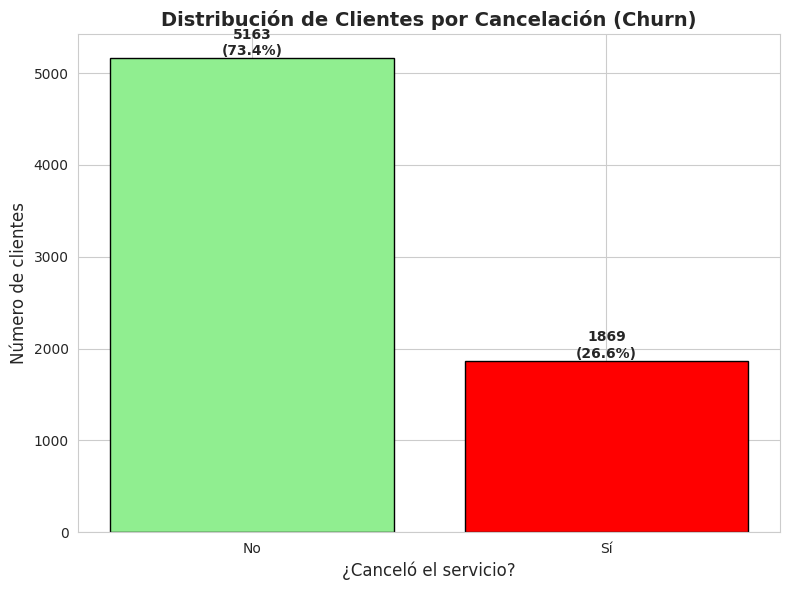

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

conteo = df['cancelacion'].value_counts()
porcentaje = df['cancelacion'].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
barras = ax.bar(conteo.index, conteo.values, color=['lightgreen', 'red'], edgecolor='black')

for barra, pct in zip(barras, porcentaje):
    height = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., height, f'{int(height)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('¿Canceló el servicio?', fontsize=12)
ax.set_ylabel('Número de clientes', fontsize=12)
ax.set_title('Distribución de Clientes por Cancelación (Churn)', fontsize=14, fontweight='bold')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 4.3 recuento de evasion por variables categoricas

In [26]:
# Análisis de impacto de variables en la cancelación

# Variables a analizar
variables_cat = [
    'genero', 'mayor_60', 'tiene_pareja', 'tiene_dependientes',
    'servicio_telefonico', 'lineas_multiples', 'servicio_internet',
    'seguridad_online', 'backup_online', 'proteccion_dispositivos',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas',
    'tipo_contrato', 'facturacion_electronica', 'metodo_pago'
]

variables_num = ['meses_contrato', 'cargo_mensual', 'total_cargos']

# Calcular impacto para cada variable
resultados = []

for var in variables_cat:
    if var in df.columns:
        tasas = df.groupby(var)['cancelacion'].apply(lambda x: (x == 'Sí').mean() * 100)
        impacto = tasas.max() - tasas.min()
        resultados.append({'Variable': var, 'Impacto': round(impacto, 1), 'Tipo': 'Diferencia %'})

for var in variables_num:
    if var in df.columns:
        df_temp = df.copy()
        df_temp['cancel_num'] = (df_temp['cancelacion'] == 'Sí').astype(int)
        correlacion = df_temp[[var, 'cancel_num']].corr().iloc[0, 1]
        impacto = abs(correlacion) * 100
        resultados.append({'Variable': var, 'Impacto': round(impacto, 1), 'Tipo': 'Correlación %'})

# Ordenar y mostrar
df_impactos = pd.DataFrame(resultados).sort_values('Impacto', ascending=False).reset_index(drop=True)

print(f"📊 Tasa global de cancelación: {(df['cancelacion'] == 'Sí').mean() * 100:.1f}%\n")
print(df_impactos.to_string(index=False))

📊 Tasa global de cancelación: 26.6%

               Variable  Impacto          Tipo
          tipo_contrato     39.9  Diferencia %
         meses_contrato     35.4 Correlación %
      servicio_internet     34.5  Diferencia %
       seguridad_online     34.3  Diferencia %
        soporte_tecnico     34.2  Diferencia %
          backup_online     32.5  Diferencia %
proteccion_dispositivos     31.7  Diferencia %
            metodo_pago     30.0  Diferencia %
    streaming_peliculas     26.3  Diferencia %
           streaming_tv     26.1  Diferencia %
           total_cargos     19.9 Correlación %
          cargo_mensual     19.3 Correlación %
               mayor_60     18.0  Diferencia %
facturacion_electronica     17.2  Diferencia %
     tiene_dependientes     15.7  Diferencia %
           tiene_pareja     13.3  Diferencia %
       lineas_multiples      3.6  Diferencia %
    servicio_telefonico      1.7  Diferencia %
                 genero      0.8  Diferencia %


/tmp/ipykernel_24421/68024263.py:29: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


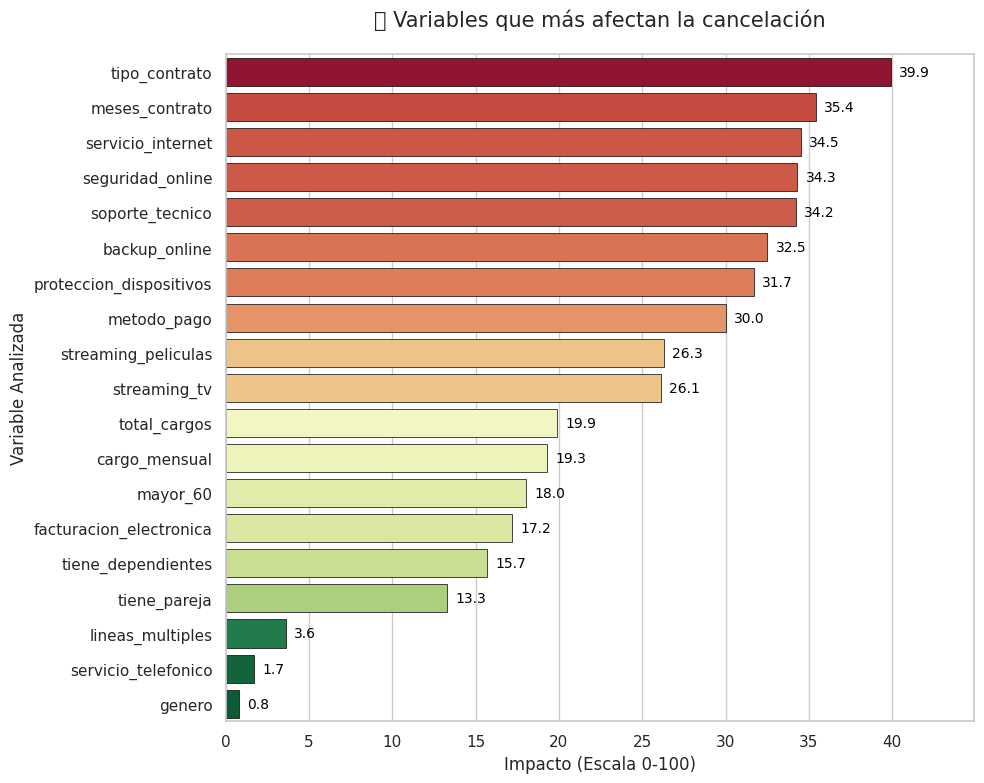

In [31]:
plot = sns.barplot(
    data=df_impactos,
    x='Impacto',
    y='Variable',
    palette='RdYlGn_r',
    hue='Impacto',
    legend=False,
    edgecolor='black',
    linewidth=0.5
)

for i, v in enumerate(df_impactos['Impacto']):
    plot.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=10, color='black')

plt.title('🎯 Variables que más afectan la cancelación', fontsize=15, pad=20)
plt.xlabel('Impacto (Escala 0-100)', fontsize=12)
plt.ylabel('Variable Analizada', fontsize=12)

plt.xlim(0, df_impactos['Impacto'].max() + 5)
plt.tight_layout()
plt.show()